## Objective

The objective of this project is to develop a deep learning-based Natural Language Processing (NLP) model to classify SMS messages as **Spam** or **Ham (legitimate)**. The project involves performing exploratory data analysis, preprocessing and tokenizing text data, converting messages into padded sequences, and building a **Bidirectional LSTM** model for classification. The model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix to assess its ability to correctly identify spam messages.


In [1]:
import pandas as pd 
import numpy as np      
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df=pd.read_csv('spam.csv')


In [3]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


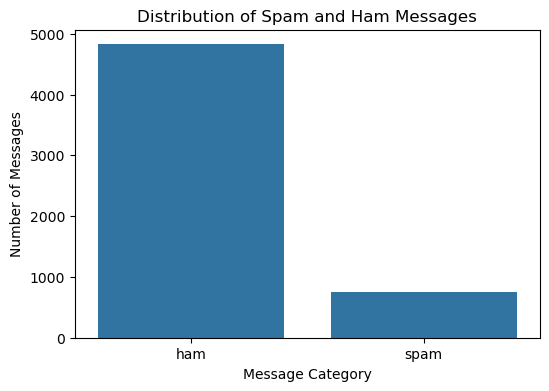

In [7]:
#Ham vs Spam count plot

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Category")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Category")
plt.ylabel("Number of Messages")
plt.show()

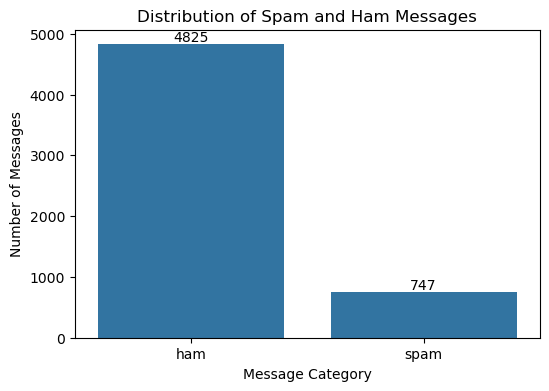

In [8]:
#Add values on top
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Category")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Category")
plt.ylabel("Number of Messages")
plt.show()

In [9]:
df["Message_Length"] = df["Message"].str.len()

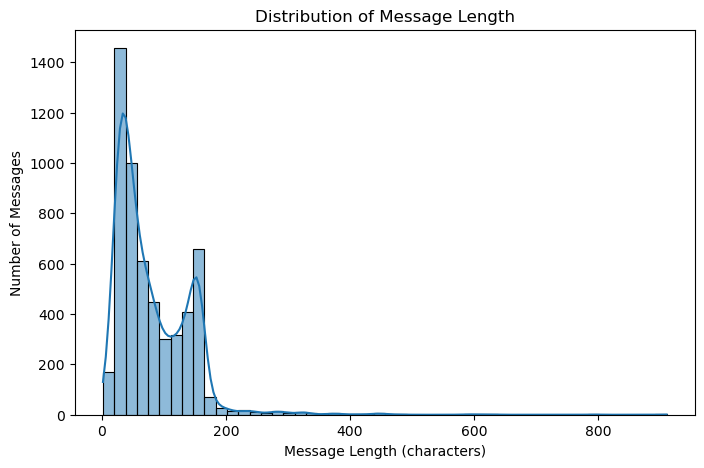

In [10]:

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Message_Length", bins=50, kde=True)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length (characters)")
plt.ylabel("Number of Messages")
plt.show()

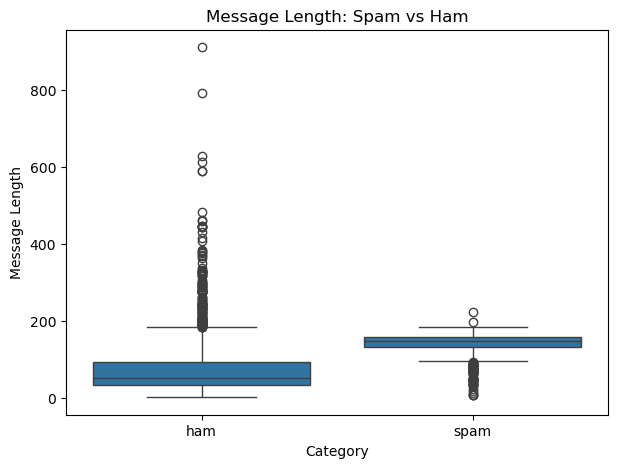

In [11]:
#Compare message length for Spam vs Ham
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Category", y="Message_Length")

plt.title("Message Length: Spam vs Ham")
plt.xlabel("Category")
plt.ylabel("Message Length")
plt.show()

In [12]:
from collections import Counter
import re

text = " ".join(df["Message"].astype(str)).lower()

words = re.findall(r"\b[a-zA-Z]+\b", text)

word_counts = Counter(words)

word_counts.most_common(20)

[('i', 3021),
 ('to', 2250),
 ('you', 2245),
 ('a', 1450),
 ('the', 1336),
 ('u', 1203),
 ('and', 980),
 ('in', 901),
 ('is', 896),
 ('me', 807),
 ('my', 766),
 ('it', 752),
 ('for', 711),
 ('your', 681),
 ('of', 623),
 ('call', 590),
 ('that', 586),
 ('s', 578),
 ('have', 575),
 ('on', 538)]

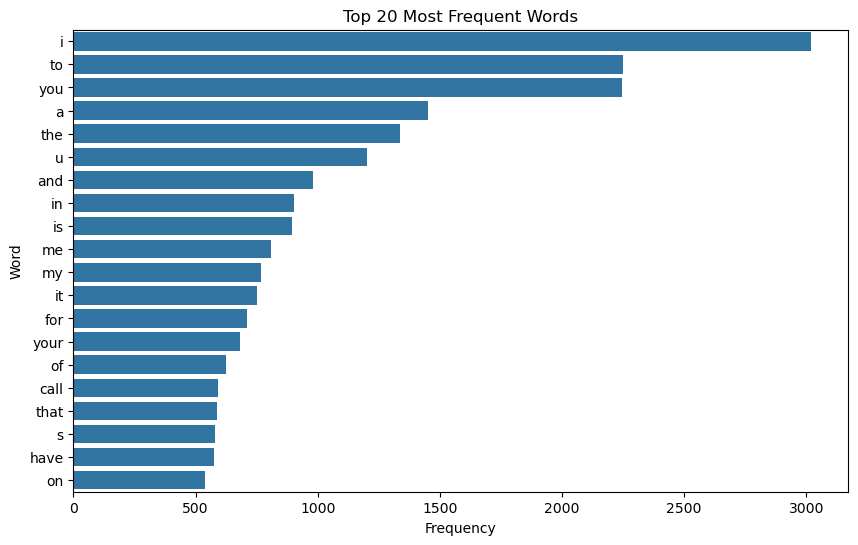

In [13]:
top_words = word_counts.most_common(20)

words_df = pd.DataFrame(top_words, columns=["Word", "Count"])

plt.figure(figsize=(10, 6))

sns.barplot(data=words_df, x="Count", y="Word")

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [14]:
df

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160
5568,ham,Will ü b going to esplanade fr home?,36
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [15]:
df.columns

Index(['Category', 'Message', 'Message_Length'], dtype='object')

In [16]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [17]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [18]:
df['Category'].value_counts()

Category
0    4825
1     747
Name: count, dtype: int64

In [19]:
df

,Category,Message,Message_Length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,160
5568,0,Will ü b going to esplanade fr home?,36
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [20]:
X = df['Message']
y = df['Category']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 4457
Testing samples: 1115

Training distribution:
Category
0    3859
1     598
Name: count, dtype: int64

Testing distribution:
Category
0    966
1    149
Name: count, dtype: int64


In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")


In [70]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{0: 0.577481212749417, 1: 3.7265886287625416}


In [73]:
class_weight=class_weights

In [90]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (4457, 189)
Testing shape: (1115, 189)


In [91]:
print("Before padding:")
print(X_train_seq[0])

print("\nAfter padding:")
print(X_train_pad[0])

Before padding:
[72, 33, 4, 339, 670]

After padding:
[ 72  33   4 339 670   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0]


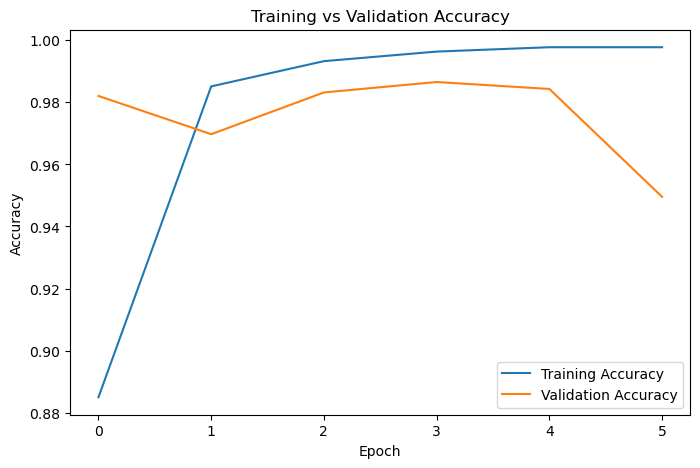

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

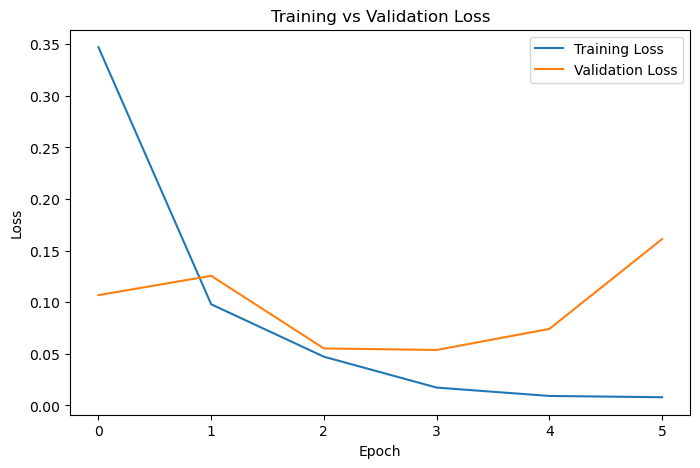

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(189,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 189, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,177 (1.47 MB)

 Trainable params: 386,177 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [99]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8864 - loss: 0.3702 - val_accuracy: 0.9608 - val_loss: 0.1511
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.9787 - loss: 0.0882 - val_accuracy: 0.9843 - val_loss: 0.0728
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.9905 - loss: 0.0493 - val_accuracy: 0.9854 - val_loss: 0.0515
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.9975 - loss: 0.0207 - val_accuracy: 0.9843 - val_loss: 0.0710
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.9983 - loss: 0.0124 - val_accuracy: 0.9865 - val_loss: 0.0563


In [100]:
train_predictions = model.predict(
    X_train_pad[:20]
).flatten()

print(train_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
[0.00538786 0.00305538 0.00182286 0.00240353 0.00157595 0.00304521
 0.01387799 0.00361    0.00252744 0.9971584  0.00353839 0.00407311
 0.00178379 0.0082457  0.00884235 0.99621004 0.00552337 0.00541415
 0.00721361 0.00785795]


In [101]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9839 - loss: 0.0558
Test Loss: 0.0558440163731575
Test Accuracy: 0.9838564991950989


In [102]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Ham', 'Spam']
    )
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.97      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



[[962   4]
 [ 14 135]]


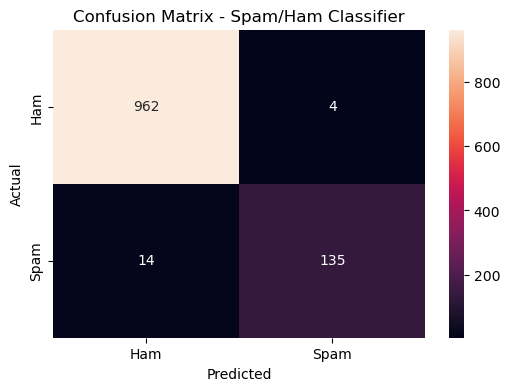

In [103]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Spam/Ham Classifier')

plt.show()

In [104]:
new_messages = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize!",
    "Hey, I'll reach home by 7 pm.",
    "URGENT! You have won 50000 rupees. Call now to claim your reward.",
    "Can you send me the notes from today's class?"
]

new_sequences = tokenizer.texts_to_sequences(new_messages)

new_padded = pad_sequences(
    new_sequences,
    maxlen=189,
    padding='post'
)

predictions = model.predict(new_padded)

for message, prediction in zip(new_messages, predictions):

    probability = float(prediction[0])

    result = "Spam" if probability >= 0.5 else "Ham"

    print(f"Message: {message}")
    print(f"Prediction: {result}")
    print(f"Spam Probability: {probability:.4f}")
    print("-" * 80)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Message: Congratulations! You have won a free iPhone. Click now to claim your prize!
Prediction: Spam
Spam Probability: 0.9960
--------------------------------------------------------------------------------
Message: Hey, I'll reach home by 7 pm.
Prediction: Ham
Spam Probability: 0.0018
--------------------------------------------------------------------------------
Message: URGENT! You have won 50000 rupees. Call now to claim your reward.
Prediction: Spam
Spam Probability: 0.9948
--------------------------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: Ham
Spam Probability: 0.0070
--------------------------------------------------------------------------------


In [105]:
# Save the trained model
model.save("spam_ham_bilstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [106]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!
